<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Petajisto%2C%20A.%20(2023).%20Underperformance%20of%20concentrated%20stock%20positions/Underperformance_of_Concentrated_Portfolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Analyze Small cap, Large cap, Mid cap  - Colab Ready
!pip install yfinance pandas numpy matplotlib seaborn tqdm --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# -------------------------
# Configuration
# -------------------------
market_ticker = "SPY"
start_date = "2000-01-01"
end_date = None
risk_free_rate = 0.0

# -------------------------
# Stock universes
# -------------------------
largecap_50 = [
    "AAPL","MSFT","AMZN","GOOGL","META","NVDA","TSLA","BRK-B","JPM","V",
    "JNJ","UNH","PG","MA","HD","BAC","DIS","ADBE","CMCSA","NFLX",
    "XOM","PFE","KO","INTC","CSCO","ORCL","T","PEP","ABT","CRM",
    "NKE","WMT","CVX","MCD","LLY","BMY","TXN","QCOM","SBUX","MDT",
    "AMGN","COST","NEE","PM","LOW","RTX","HON","UPS","SCHW","GS"
]

midcap_50 = [
    "ALGN","AAP","AIZ","AKAM","ALB","AMCR","AN","AVY","BALL","BERY",
    "BIO","BRO","CBOE","CINF","CMC","CPRT","CSGP","DINO","EXPD","FDS",
    "FMC","GL","HAS","HOLX","IEX","IP","JBL","JKHY","KMX","LEA",
    "MAS","MKC","MLM","NDSN","NVR","OGE","ORI","PFGC","PKG","PWR",
    "RHI","RNR","RSG","SEE","SNA","SWK","TDY","TFX","TPR","WAB"
]

smallcap_50 = [
    "AAN","ABG","ABM","AEO","AIT","APOG","ARCB","ASGN","ATGE","AVNT",
    "B","BCC","BKE","BRC","BSET","BZH","CATO","CENX","CHEF","CMLS",
    "COKE","COLM","CR","CRMT","CRUS","CTS","CUTR","DAKT","DORM","EBF",
    "EVC","FLXS","GCO","GHC","GIII","HIBB","HNI","HOFT","HURC","IESC",
    "IVC","KELYA","KLIC","LANC","LZB","MBUU","MLI","MOV","NATH"
]

# -------------------------
# SELECT WHICH GROUP TO ANALYZE
# -------------------------
tickers = smallcap_50 + midcap_50 + largecap_50 # <-- change to largecap_50 or midcap_50

print("Analyzing", len(tickers), "tickers.")

# -------------------------
# Download price data
# -------------------------
all_tickers = [market_ticker] + tickers
print("Downloading price data...")

prices = (
    yf.download(
        tickers=all_tickers,
        start=start_date,
        end=end_date,
        progress=False,
        auto_adjust=True
    )
    .loc[:, "Close"]
    .dropna(how="all")
)

prices = prices.sort_index()
print("Price data range:", prices.index.min().date(), "to", prices.index.max().date())

# Drop tickers with insufficient data
min_obs = int(0.8 * len(prices))
valid_tickers = [t for t in tickers if prices[t].dropna().shape[0] >= min_obs]

if len(valid_tickers) < len(tickers):
    print("Dropped:", set(tickers) - set(valid_tickers))

tickers = valid_tickers
prices = prices[[market_ticker] + tickers]

# -------------------------
# Compute returns and metrics
# -------------------------
returns = prices.pct_change().dropna()
cum_returns = (1 + returns).cumprod()

trading_days = 252

def ann_return(series):
    total = (1 + series).prod()
    years = len(series) / trading_days
    return total ** (1 / years) - 1

def ann_vol(series):
    return series.std() * np.sqrt(trading_days)

def sharpe(series):
    excess = series - risk_free_rate / trading_days
    return ann_return(excess) / ann_vol(excess)

def max_drawdown(cum):
    peak = cum.cummax()
    return ((cum - peak) / peak).min()

# Compute metrics
metrics = []
for t in tickers:
    r = returns[t]
    cum = cum_returns[t]
    metrics.append({
        "ticker": t,
        "ann_return": ann_return(r),
        "ann_vol": ann_vol(r),
        "sharpe": sharpe(r),
        "max_drawdown": max_drawdown(cum)
    })

metrics_df = pd.DataFrame(metrics).set_index("ticker").sort_values("ann_return", ascending=False)

# Market metrics
market_r = returns[market_ticker]
market_metrics = {
    "ann_return": ann_return(market_r),
    "ann_vol": ann_vol(market_r),
    "sharpe": sharpe(market_r),
    "max_drawdown": max_drawdown(cum_returns[market_ticker])
}

# -------------------------
# Market-adjusted performance
# -------------------------
total_years = (prices.index[-1] - prices.index[0]).days / 365.25
total_returns = prices.iloc[-1] / prices.iloc[0] - 1
ann_total_returns = (1 + total_returns) ** (1 / total_years) - 1

rel_perf = pd.DataFrame({
    "ann_return": ann_total_returns[tickers],
})
rel_perf["market_ann"] = ann_total_returns[market_ticker]
rel_perf["market_adj_ann"] = rel_perf["ann_return"] - rel_perf["market_ann"]

summary = metrics_df.join(rel_perf["market_adj_ann"])

# -------------------------
# Output
# -------------------------
pd.set_option("display.float_format", "{:.2%}".format)

print("\nMarket metrics:")
display(pd.DataFrame([market_metrics]))

print("\nTop 10 performers:")
display(metrics_df.head(10))

print("\nBottom 10 performers:")
display(metrics_df.tail(10))

print("\nMarket-adjusted performance:")
display(summary.sort_values("market_adj_ann"))

frac_under = (summary["market_adj_ann"] < 0).mean()
print(f"\nFraction underperforming the market: {frac_under:.2%}")



Analyzing 149 tickers.


ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['IVC', 'AAN', 'BERY', 'HIBB']: YFTzMissingError('possibly delisted; no timezone found')


Price data range: 2000-01-03 to 2026-03-25
Dropped: {'LANC', 'CBOE', 'AAN', 'AMCR', 'TSLA', 'CR', 'MBUU', 'V', 'BCC', 'PM', 'CUTR', 'HIBB', 'BERY', 'CHEF', 'META', 'IVC', 'LEA', 'MA', 'PFGC'}

Market metrics:


,ann_return,ann_vol,sharpe,max_drawdown
0,10.70%,18.87%,56.71%,-55.19%



Top 10 performers:


...


Bottom 10 performers:


,ann_return,ann_vol,sharpe,max_drawdown
ticker,,,,
HURC,2.59%,47.13%,5.49%,-86.03%
RHI,1.81%,34.20%,5.28%,-79.39%
GCO,1.28%,54.73%,2.34%,-90.10%
HOFT,-0.81%,45.21%,-1.80%,-80.96%
EVC,-1.37%,85.88%,-1.60%,-98.65%
CRMT,-2.26%,48.59%,-4.65%,-93.52%
CATO,-3.00%,45.23%,-6.64%,-90.65%
KELYA,-3.62%,41.26%,-8.76%,-80.64%
BZH,-9.22%,68.25%,-13.50%,-99.69%



Market-adjusted performance:


,ann_return,ann_vol,sharpe,max_drawdown,market_adj_ann
ticker,,,,,
CMLS,-38.35%,10020.17%,-0.38%,-100.00%,-43.39%
AKAM,10.35%,41.34%,25.03%,-84.29%,-11.52%
KELYA,-3.62%,41.26%,-8.76%,-80.64%,-10.17%
BZH,-9.22%,68.25%,-13.50%,-99.69%,-9.55%
CTS,8.14%,43.01%,18.93%,-86.27%,-8.45%
...,...,...,...,...,...
ALGN,12.22%,51.14%,23.89%,-82.89%,NaN
TPR,11.91%,41.43%,28.74%,-82.39%,NaN
AAP,4.54%,38.24%,11.86%,-86.41%,NaN



Fraction underperforming the market: 36.15%


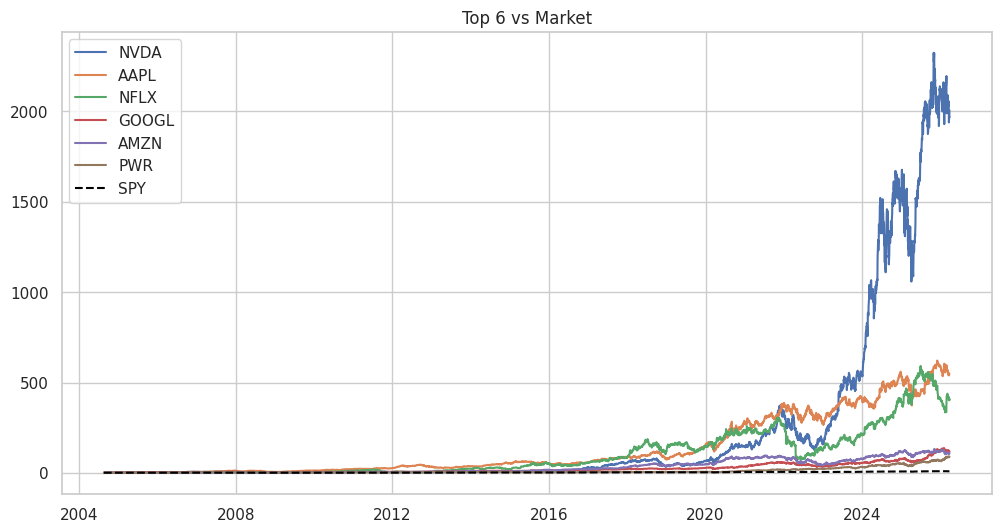

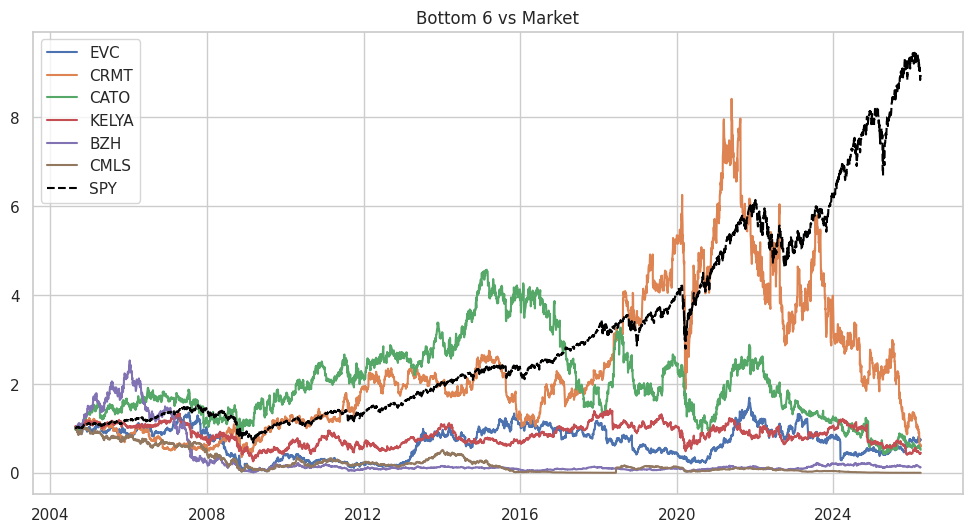

In [2]:
# -------------------------
# Plots
# -------------------------
plt.figure()
for t in metrics_df.head(6).index:
    plt.plot(cum_returns[t], label=t)
plt.plot(cum_returns[market_ticker], label=market_ticker, linestyle="--", color="black")
plt.title("Top 6 vs Market")
plt.legend()
plt.show()

plt.figure()
for t in metrics_df.tail(6).index:
    plt.plot(cum_returns[t], label=t)
plt.plot(cum_returns[market_ticker], label=market_ticker, linestyle="--", color="black")
plt.title("Bottom 6 vs Market")
plt.legend()
plt.show()

This code creates two line charts comparing stock performance to the market. The first chart plots the cumulative returns of the six best-performing stocks against the market, while the second chart shows the six worst-performing stocks compared to the market. Each plot includes a dashed black line representing the market, making it easy to see which stocks outperformed or underperformed over time.

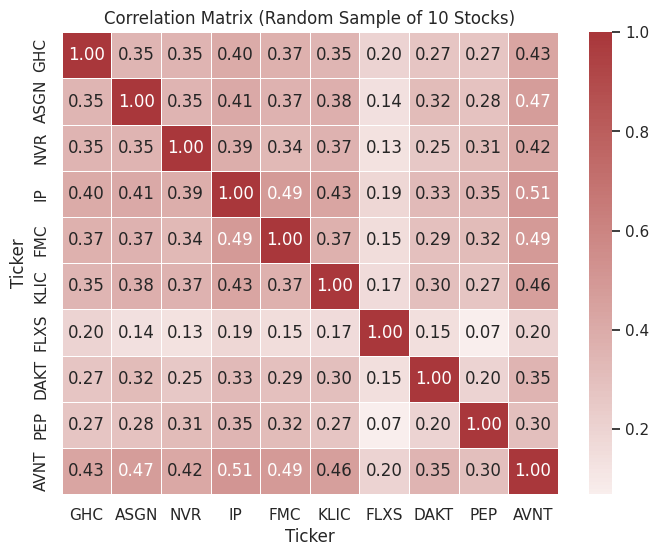

In [3]:
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
random.seed(42)

# Randomly select 10 tickers
sampled_tickers = random.sample(tickers, 10)

# Compute correlation matrix
sample_corr = returns[sampled_tickers].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(sample_corr, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Random Sample of 10 Stocks)")
plt.show()

This code randomly selects 10 stocks from the full list of tickers and calculates the correlation of their returns. It then visualizes these relationships as a heatmap, with colors indicating how strongly each pair of stocks moves together. Positive values show stocks that tend to move in the same direction, negative values show stocks that move in opposite directions, and values near zero indicate little relationship. The heatmap provides a quick way to see which stocks are highly correlated within this random sample.

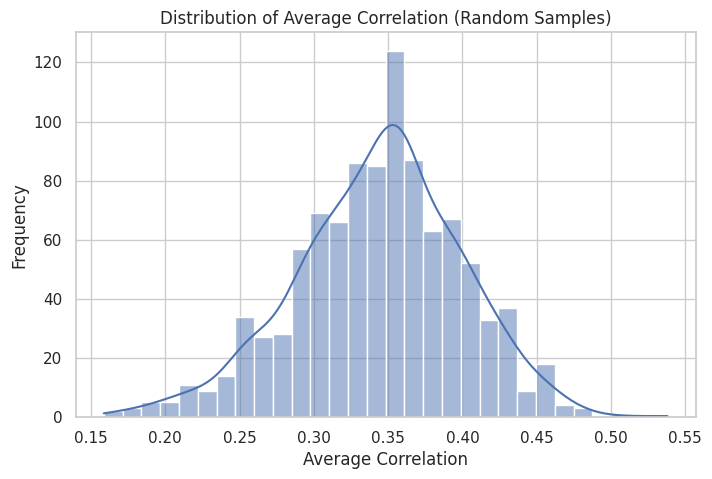

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def sample_avg_correlation(returns, tickers, sample_size=6, n_samples=1000):
    avg_corrs = []

    for _ in range(n_samples):
        sampled = random.sample(tickers, sample_size)
        corr_matrix = returns[sampled].corr()

        # Take upper triangle (exclude diagonal)
        upper_vals = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        ).stack()

        avg_corrs.append(upper_vals.mean())

    return avg_corrs

# Run sampling
avg_corrs = sample_avg_correlation(returns, tickers, sample_size=6, n_samples=1000)

# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(avg_corrs, bins=30, kde=True)
plt.title("Distribution of Average Correlation (Random Samples)")
plt.xlabel("Average Correlation")
plt.ylabel("Frequency")
plt.show()

This graph shows the distribution of average correlations calculated from many randomly sampled subgroups of stocks. For each sample, a small set of stocks is randomly selected, the pairwise correlations among them are computed, and the mean of those correlations is recorded. Repeating this process hundreds or thousands of times creates a distribution that reflects the typical level of co-movement within the stock universe and how it varies across different possible combinations.

The significance of this graph is that it illustrates the variability of correlations depending on which stocks are selected, rather than relying on a single fixed correlation matrix for the full universe. It highlights the expected range of average correlations one might encounter when constructing small portfolios, providing a realistic view of diversification potential and showing that some random combinations of stocks can be much more correlated, or much less correlated, than others.

[*********************100%***********************]  151 of 151 completed


Data: 1999-01-04 → 2026-03-25
Each window needs 15 years of data

Candidate eval dates (monthly): 146
  First: 2004-02-02  Last: 2016-03-01

Best non-overlapping arrangement: 2 windows
  eval=2004-02-02  lookback=[1999-02-02 → 2004-02-02]  forward=[2004-02-02 → 2014-02-02]
  eval=2014-02-03  lookback=[2009-02-03 → 2014-02-03]  forward=[2014-02-03 → 2024-02-03]


Windows: 100%|██████████| 2/2 [00:00<00:00, 12.34it/s]

  2004-02-02: 150 stocks  |  SPY fwd ann: 6.70%
  2014-02-03: 150 stocks  |  SPY fwd ann: 13.02%


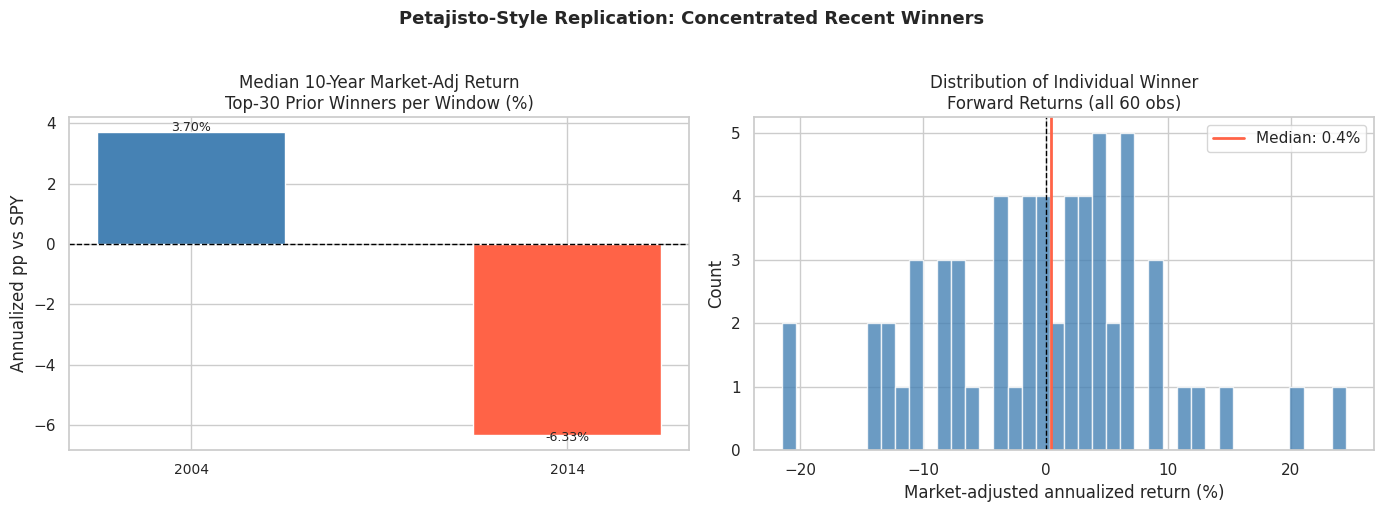


Petajisto Replication  |  Top-30 | 2 windows found
Windows where median underperforms:  50%

  [2004]  median adj: +3.70%  |  mean adj: +3.68%  |  % neg: 27%  |  SPY: +6.70%
  winners: ['NVR', 'DAKT', 'KMX', 'EWBC', 'BIO', 'UNH', 'COLM', 'CRMT', 'BRO', 'GGG', 'AKR', 'SYK', 'EQT', 'ARCB', 'GIII', 'EXPD', 'DCI', 'CATO', 'BALL', 'CPRT', 'ETN', 'CENX', 'FICO', 'CHRW', 'CMC', 'EME', 'GCO', 'MMM', 'MKC', 'AIT']

  [2014]  median adj: -6.33%  |  mean adj: -4.20%  |  % neg: 70%  |  SPY: +13.02%
  winners: ['LZB', 'AVNT', 'GIII', 'DORM', 'KLIC', 'BSET', 'ASGN', 'IP', 'BWA', 'KMX', 'AAPL', 'AOS', 'PKG', 'FLXS', 'MOV', 'AN', 'BDC', 'GCO', 'NDSN', 'WAB', 'VFC', 'EXP', 'CSL', 'AZZ', 'SHW', 'FICO', 'CTS', 'CRMT', 'GL', 'ETN']

Overall median: +0.45%
Overall mean:   -0.26%
Total obs:      60

NOTE: survivorship bias present. Use CRSP for more rigorous results!!.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 1 — Find ALL valid non-overlapping window sets, pick the best one
# ─────────────────────────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from itertools import combinations

largecap_final = [
    'AAPL','MSFT','JPM','JNJ','XOM','KO','PG','WMT','BAC','GE',
    'T','CVX','PFE','MRK','IBM','INTC','CSCO','AMGN','UPS','HON',
    'MMM','CAT','DE','EMR','ETN','GD','GIS','HIG','ITW','LMT',
    'LOW','MCD','MDT','MO','NKE','NOC','NSC','OMC','PEP','RTX',
    'SHW','SLB','SYK','TGT','TXN','UNH','USB','VFC','WFC','ABT'
]
midcap_final = [
    'AKAM','ALB','AN','AVY','BALL','BIO','BRO','CINF','CMC','CPRT',
    'EXPD','FDS','FMC','GL','HAS','IEX','IP','JBL','JKHY','KMX',
    'MAS','MKC','MLM','NDSN','NVR','ORI','PKG','PWR','RHI','RSG',
    'SEE','SNA','SWK','TFX','WAB','AOS','BWA','CHRW','CLF','CSL',
    'DCI','EFX','EHC','EME','EQT','EWBC','EXP','FICO','FIX','GGG'
]
smallcap_final = [
    'ABM','AEO','AIT','APOG','ARCB','ATGE','B','BKE','BRC','BSET',
    'CATO','CENX','COKE','COLM','CRMT','CTS','DAKT','DORM','FLXS','GCO',
    'GHC','GIII','HNI','KELYA','KLIC','LZB','MLI','MOV','NATH','HURC',
    'IESC','ACNB','AIN','AKR','ALEX','AMWD','ANF','AROW','ARWR','ASB',
    'ASGN','ASTE','AVA','AVNT','AWR','AZZ','BANF','BANR','BDC','BHB'
]

tickers       = largecap_final + midcap_final + smallcap_final
market_ticker = "SPY"

# ── Download ──────────────────────────────────────────────────────────────────
print("Downloading prices...")
raw    = yf.download(tickers + [market_ticker], start="1999-01-01",
                     auto_adjust=True, progress=True)
prices = raw["Close"].ffill(limit=5)
prices.index = pd.to_datetime(prices.index)

dates         = prices.index
data_start    = dates[0]
data_end      = dates[-1]
lookback_years = 5
forward_years  = 10
window_years   = lookback_years + forward_years  # 15 years per window
MIN_OBS        = 200
TOP_N_WINNERS  = 30

print(f"Data: {data_start.date()} → {data_end.date()}")
print(f"Each window needs {window_years} years of data")

# ─────────────────────────────────────────────────────────────────────────────
# Key fix: enumerate ALL candidate eval dates (monthly steps across valid range)
# then find the arrangement that maximises the number of non-overlapping windows
# ─────────────────────────────────────────────────────────────────────────────

# A valid eval date must have:
#   - lookback_years of history before it
#   - forward_years of data after it
earliest_eval = data_start + pd.DateOffset(years=lookback_years)
latest_eval   = data_end   - pd.DateOffset(years=forward_years)

# Generate candidate eval dates on monthly grid
candidate_evals = pd.date_range(earliest_eval, latest_eval, freq="MS")
candidate_evals = [prices.index[prices.index.searchsorted(d)]
                   for d in candidate_evals
                   if d <= latest_eval]

print(f"\nCandidate eval dates (monthly): {len(candidate_evals)}")
print(f"  First: {candidate_evals[0].date()}  Last: {candidate_evals[-1].date()}")

# Greedy algorithm: find maximum non-overlapping set
# Windows don't overlap if eval dates are at least forward_years apart
# Try ALL possible starting points and pick the arrangement with most windows
def greedy_nonoverlap(candidates, min_gap_years):
    """Given sorted candidate dates, greedily pick max non-overlapping set."""
    selected = [candidates[0]]
    for d in candidates[1:]:
        if d >= selected[-1] + pd.DateOffset(years=min_gap_years):
            selected.append(d)
    return selected

# Try starting from every candidate and keep the arrangement with most windows
best_windows = []
for start_idx in range(len(candidate_evals)):
    subset   = candidate_evals[start_idx:]
    selected = greedy_nonoverlap(subset, forward_years)
    if len(selected) > len(best_windows):
        best_windows = selected

print(f"\nBest non-overlapping arrangement: {len(best_windows)} windows")
for d in best_windows:
    fwd_end = d + pd.DateOffset(years=forward_years)
    print(f"  eval={d.date()}  "
          f"lookback=[{(d - pd.DateOffset(years=lookback_years)).date()} → {d.date()}]  "
          f"forward=[{d.date()} → {fwd_end.date()}]")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 — Compute returns for each window
# ─────────────────────────────────────────────────────────────────────────────
results = []

for eval_date in tqdm(best_windows, desc="Windows"):
    prior_start = eval_date - pd.DateOffset(years=lookback_years)
    forward_end = eval_date + pd.DateOffset(years=forward_years)

    m_start    = prices.loc[:eval_date,   market_ticker].iloc[-1]
    m_end      = prices.loc[:forward_end, market_ticker].iloc[-1]
    market_ann = (m_end / m_start) ** (1 / forward_years) - 1

    rows = []
    for t in tickers:
        if t not in prices.columns:
            continue
        try:
            ps = prices.loc[prior_start:eval_date,  t].dropna()
            fs = prices.loc[eval_date:forward_end,   t].dropna()
            if len(ps) < MIN_OBS or len(fs) < MIN_OBS:
                continue
            prior_ann   = (ps.iloc[-1] / ps.iloc[0]) ** (1 / lookback_years) - 1
            forward_ann = (fs.iloc[-1] / fs.iloc[0]) ** (1 / forward_years)  - 1
            rows.append((t, prior_ann, forward_ann, forward_ann - market_ann))
        except Exception:
            continue

    df = pd.DataFrame(rows, columns=["ticker","prior_ann","forward_ann","market_adj_ann"])
    results.append((eval_date, df, market_ann))
    print(f"  {eval_date.date()}: {len(df)} stocks  |  SPY fwd ann: {market_ann:.2%}")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 — Winner selection + stats
# ─────────────────────────────────────────────────────────────────────────────
winner_rows    = []
all_winner_ret = []

for eval_date, df, market_ann in results:
    if len(df) < TOP_N_WINNERS:
        print(f"⚠ {eval_date.date()}: only {len(df)} stocks, skipping")
        continue
    winners = df.nlargest(TOP_N_WINNERS, "prior_ann").copy()
    all_winner_ret.extend(winners["market_adj_ann"].tolist())
    winner_rows.append({
        "eval_date":             eval_date,
        "market_ann":            market_ann,
        "median_prior_ann":      winners["prior_ann"].median(),
        "median_market_adj_ann": winners["market_adj_ann"].median(),
        "mean_market_adj_ann":   winners["market_adj_ann"].mean(),
        "pct_negative":          (winners["market_adj_ann"] < 0).mean(),
        "n_winners":             len(winners),
        "n_stocks":              len(df),
        "winners":               winners["ticker"].tolist(),
    })

summary = pd.DataFrame(winner_rows).set_index("eval_date")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 4 — Plot
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ["tomato" if v < 0 else "steelblue"
          for v in summary["median_market_adj_ann"]]
bars = ax.bar(range(len(summary)), summary["median_market_adj_ann"] * 100,
              color=colors, width=0.5)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xticks(range(len(summary)))
ax.set_xticklabels([str(d.year) for d in summary.index], fontsize=10)
ax.set_title(f"Median 10-Year Market-Adj Return\nTop-{TOP_N_WINNERS} Prior Winners per Window (%)")
ax.set_ylabel("Annualized pp vs SPY")
for bar, val in zip(bars, summary["median_market_adj_ann"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.05 if val >= 0 else -0.2),
            f"{val*100:.2f}%", ha="center", fontsize=9)

ax2 = axes[1]
ax2.hist([x*100 for x in all_winner_ret], bins=40,
         color="steelblue", edgecolor="white", alpha=0.8)
med = np.median(all_winner_ret)
ax2.axvline(0,       color="black", linestyle="--", linewidth=1)
ax2.axvline(med*100, color="tomato", linestyle="-", linewidth=2,
            label=f"Median: {med*100:.1f}%")
ax2.set_title(f"Distribution of Individual Winner\nForward Returns (all {len(all_winner_ret)} obs)")
ax2.set_xlabel("Market-adjusted annualized return (%)")
ax2.set_ylabel("Count")
ax2.legend()

plt.suptitle("Petajisto-Style Replication: Concentrated Recent Winners",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Print stats ───────────────────────────────────────────────────────────────
frac_neg = (summary["median_market_adj_ann"] < 0).mean()
print("\n" + "="*60)
print(f"Petajisto Replication  |  Top-{TOP_N_WINNERS} | {len(best_windows)} windows found")
print("="*60)
print(f"Windows where median underperforms:  {frac_neg:.0%}")
for _, row in summary.iterrows():
    print(f"\n  [{row.name.year}]  "
          f"median adj: {row['median_market_adj_ann']:+.2%}  |  "
          f"mean adj: {row['mean_market_adj_ann']:+.2%}  |  "
          f"% neg: {row['pct_negative']:.0%}  |  "
          f"SPY: {row['market_ann']:+.2%}")
    print(f"  winners: {row['winners']}")

print(f"\nOverall median: {np.median(all_winner_ret):+.2%}")
print(f"Overall mean:   {np.mean(all_winner_ret):+.2%}")
print(f"Total obs:      {len(all_winner_ret)}")
print("\nNOTE: survivorship bias present. Use CRSP for more rigorous results!!.")

In the first, starting in 2004, the code identified the 30 stocks that had performed best over the prior five years and then tracked how they did over the next decade. Those stocks beat the market by an average of 3.70 percent per year. Momentum persisted, and concentrating in prior winners actually worked. In the second experiment, starting in 2014, the code did the exact same thing with a fresh set of 30 prior winners, and those stocks went on to underperform the market by an average of 6.33 percent per year over the following decade. That represents an enormous gap. A fund concentrated in those 2014 winners did not just slightly lag the S&P, it fell behind by over six percentage points annually for ten straight years.

The right graph shows all 60 individual stock outcomes pooled across both experiments. The spread is wide, ranging from about minus 25 percent to plus 25 percent annualized, which indicates that within any given "winner" portfolio there is enormous dispersion. Some prior winners kept compounding, while others collapsed. The median sits just barely above zero at 0.4 percent, meaning roughly half of all individual winner stocks beat the market and half did not, almost a coin flip at the stock level. The important thing the distribution shows is that it is not a clean leftward skew as Petajisto would predict universally. The 2004 cohort is pulling the right tail up and masking what the 2014 cohort alone would show, which is a distribution shifted meaningfully to the left.